# Notebook 01t - PPO baseline on `Taxi-v4`

Train the standard PPO baseline for Taxi using `config/envs/taxi.yaml`.
Taxi is discrete and deterministic, but PPO can still fail by assigning almost
zero probability to the mandatory `pickup` and `dropoff` actions. Read the
action-probability panel alongside return and success.


---
## Knobs


In [1]:
# ----------------------------------------------------------------------------
# EDIT ME
# ----------------------------------------------------------------------------
ENV_CONFIG    = "taxi_cf"
SEEDS         = [0,]          # None -> use the config's seeds
FORCE_RETRAIN = True

OVERRIDES = {
    # "ppo.total_timesteps": 200_000,
    # "run.seeds": (0,),
    # "ppo.prob_floor_start": 0.20,
    # "ppo.prob_floor_end": 0.01,
}
# ----------------------------------------------------------------------------


## 0. Setup


In [2]:
%load_ext autoreload
%autoreload 2

import sys, pathlib, time

ROOT = pathlib.Path.cwd()
if not (ROOT / "config").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import make_config, seed_dir, RUNS_DIR, FIGURES_DIR
from dataio import load_trajectories, validate, load_checkpoint, list_checkpoints
from utils.logging import read_scalars
from utils.plotting import plot_learning_curves, plot_episode_returns, plot_grid, savefig
from scripts.train import run_seeds

cfg = make_config(ENV_CONFIG, **OVERRIDES)
if SEEDS is not None:
    cfg = make_config(ENV_CONFIG, **{**OVERRIDES, "run.seeds": tuple(SEEDS)})
SEEDS = tuple(cfg.run.seeds)
RUN_NAME = cfg.run.run_name
FIG = FIGURES_DIR / f"nb01_{RUN_NAME}"
FIG.mkdir(parents=True, exist_ok=True)

ACTION_NAMES = ["south", "north", "east", "west", "pickup", "dropoff"]
print(cfg.summary())
print()
print(f"run: {RUN_NAME}   seeds: {list(SEEDS)}")


config             taxi_cf
env                Taxi-v4  (n_envs=16, obs_norm=onehot)
layouts            random every episode
total_timesteps    1,000,000  per seed
rollout batch      1024  (16 envs x 64 steps)
updates            976
minibatch size     256  x 4 epochs
gamma / lambda     0.99 / 0.98
lr                 0.0007  (anneal=True)
encoder            mlp  (shared=False)
entropy            adaptive, coef 0.003
prob floor         0.2 -> 0.01  (0 = off)
adv norm           minibatch  (min_std 1e-06)
policy gradient    cf_all_action  alpha_gae=1.0 alpha_cf=0.5, Q_g horizon=32 x2 rollouts, subsample=10%, restore=exact
reward shaping     off
warm start         none
seeds              [0]
checkpoints at     ['10%', '30%', '50%', '75%', '100%']

run: taxi   seeds: [0]


## 1. Train


In [3]:
already = all((seed_dir(RUN_NAME, s) / "scalars.csv").exists() for s in SEEDS)

if already and not FORCE_RETRAIN:
    print(f"found existing run at {RUNS_DIR / RUN_NAME} -- skipping training")
else:
    t0 = time.time()
    outputs = run_seeds(cfg)
    print()
    print(f"training finished in {(time.time() - t0) / 60:.1f} min")



=== seed 0 ====================================================
  oracle check: replay exact over 96 transitions (reward err 0, state err 0); centering max 2.00e-05
  upd    10/976  step   10,240  ret -618.875  succ 0.00  sg1 0.00 sg2 0.00  ent 1.535  advstd 1.32e+01  ev -0.017  2,475 sps
  upd    20/976  step   20,480  ret -467.656  succ 0.00  sg1 0.00 sg2 0.00  ent 1.462  advstd 1.39e+01  ev -0.013  2,840 sps
  upd    30/976  step   30,720  ret -316.280  succ 0.00  sg1 0.00 sg2 0.00  ent 1.487  advstd 1.34e+01  ev -0.000  2,891 sps
  upd    40/976  step   40,960  ret -307.680  succ 0.01  sg1 0.00 sg2 0.00  ent 1.415  advstd 1.09e+01  ev  0.001  2,931 sps
  upd    50/976  step   51,200  ret -309.880  succ 0.02  sg1 0.00 sg2 0.00  ent 1.221  advstd 1.26e+01  ev  0.002  3,008 sps
  upd    60/976  step   61,440  ret -316.680  succ 0.01  sg1 0.00 sg2 0.00  ent 1.077  advstd 1.16e+01  ev  0.000  3,051 sps
  upd    70/976  step   71,680  ret -312.050  succ 0.00  sg1 0.00 sg2 0.00  ent 1.23

## 2. Load Outputs


In [4]:
scalars = {}
episodes = {}
for s in SEEDS:
    sd = seed_dir(RUN_NAME, s)
    if (sd / "scalars.csv").exists():
        scalars[s] = read_scalars(sd / "scalars.csv")
    if (sd / "episodes.csv").exists():
        episodes[s] = pd.read_csv(sd / "episodes.csv")

summary = []
for s, d in scalars.items():
    row = {
        "seed": s,
        "steps": int(d["global_step"].iloc[-1]),
        "final_return_100": round(float(d["mean_return_100"].iloc[-1]), 2),
        "final_success_100": round(float(d["success_rate_100"].iloc[-1]), 3),
        "best_success_100": round(float(d["success_rate_100"].max()), 3),
        "median_entropy": round(float(d["entropy"].median()), 3),
        "median_ev": round(float(d["explained_variance"].median()), 3),
    }
    summary.append(row)
display(pd.DataFrame(summary))


,seed,steps,final_return_100,final_success_100,best_success_100,median_entropy,median_ev
0,0,999424,-84.71,0.69,0.83,0.656,0.559


## 3. Return, Success, And Optimisation


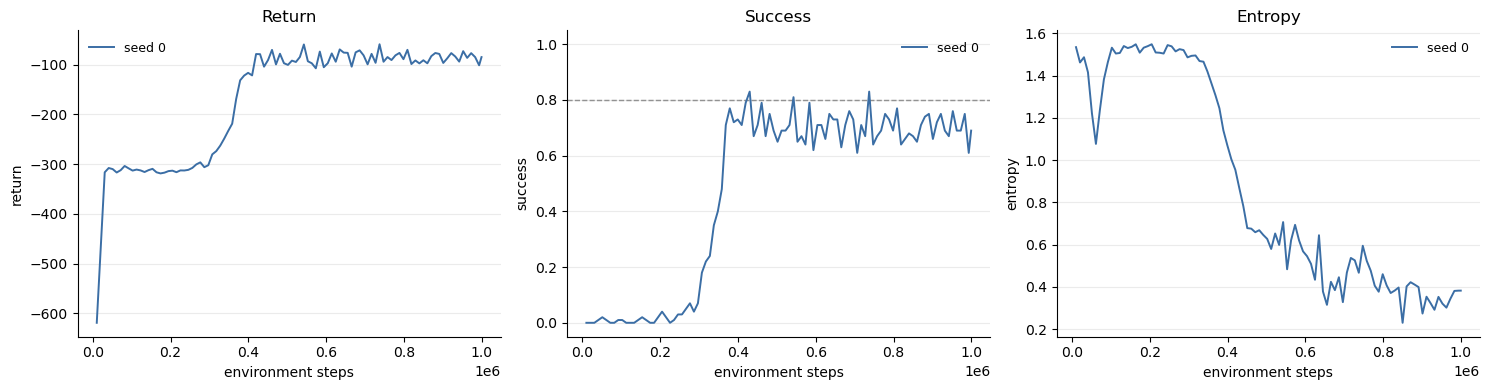

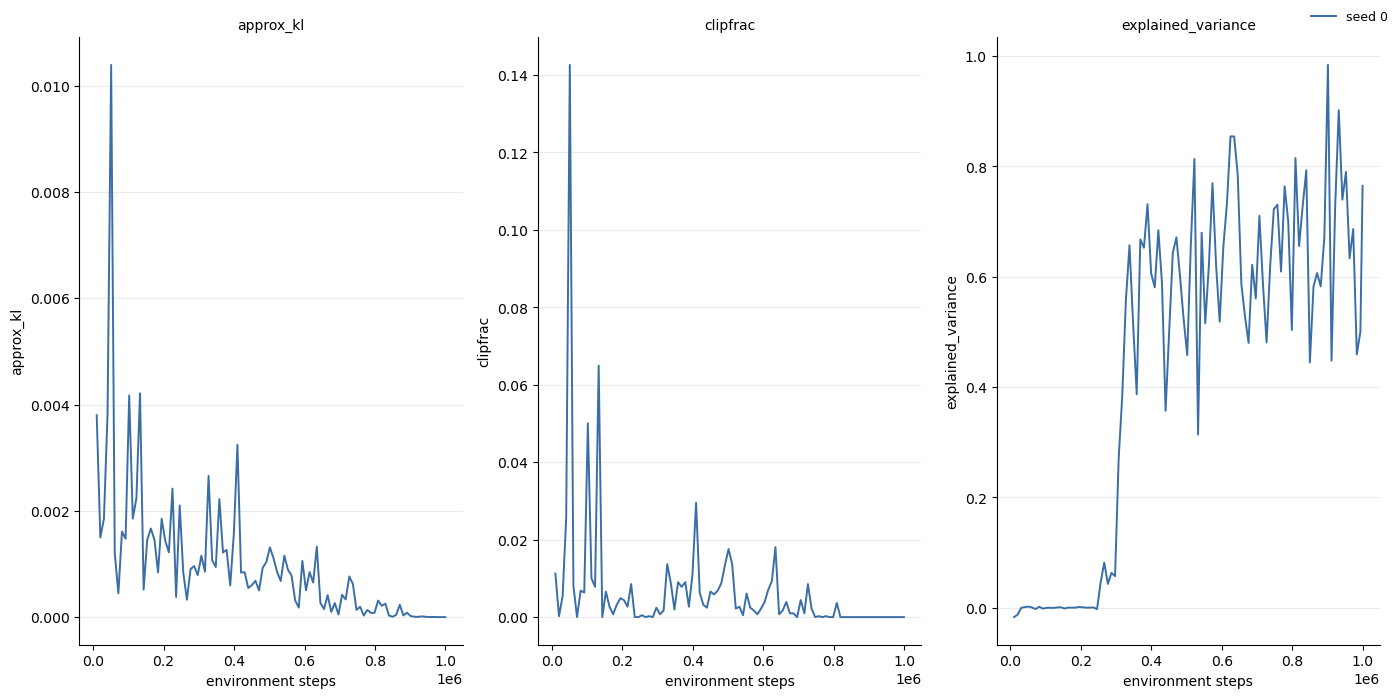

In [5]:
if scalars:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    plot_learning_curves(scalars, y="mean_return_100", ylabel="return", title="Return", ax=axes[0])
    plot_learning_curves(scalars, y="success_rate_100", ylabel="success", title="Success", hline=0.8, ax=axes[1])
    plot_learning_curves(scalars, y="entropy", ylabel="entropy", title="Entropy", ax=axes[2])
    axes[1].set_ylim(-0.05, 1.05)
    fig.tight_layout()
    savefig(fig, FIG / "learning.png")
    plt.show()

    keys = [k for k in ["loss", "policy_loss", "value_loss", "approx_kl", "clipfrac", "adv_std", "explained_variance"]
            if k in next(iter(scalars.values())).columns]
    fig = plot_grid(scalars, keys, ncols=3, figsize=(14, 7))
    savefig(fig, FIG / "optimisation.png")
    plt.show()


## 4. Taxi Action Diagnostics


,seed,action,sample_frac,mean_pi,p05_pi,p95_pi
0,0,south,0.229678,0.229501,0.006241,0.957619
1,0,north,0.149988,0.150456,0.005624,0.504251
2,0,east,0.375645,0.375560,0.006344,0.969423
3,0,west,0.202848,0.202429,0.005912,0.936195
4,0,pickup,0.021122,0.021145,0.005229,0.033662
5,0,dropoff,0.020718,0.020909,0.005229,0.033609


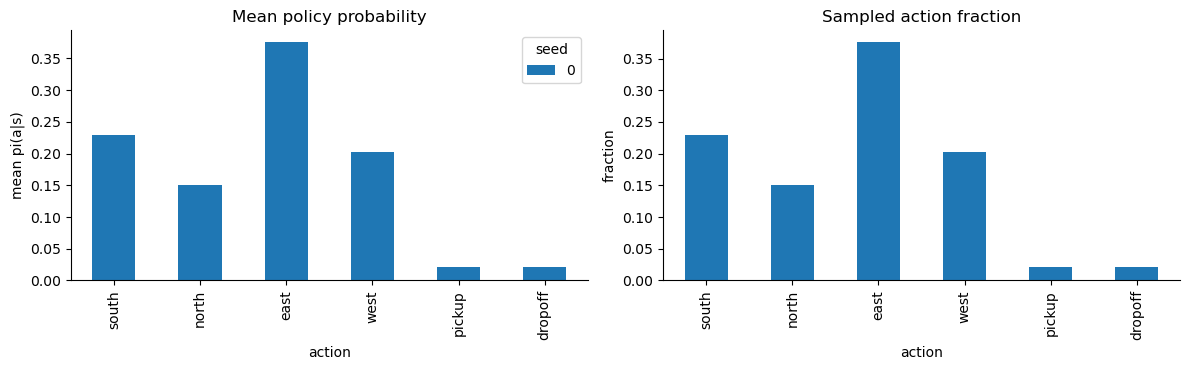

,seed,component,value,visit_frac
0,0,taxi_row,0,0.457496
1,0,taxi_row,1,0.397571
2,0,taxi_row,2,0.144933
3,0,taxi_col,0,0.233526
4,0,taxi_col,1,0.134979
5,0,taxi_col,2,0.217400
6,0,taxi_col,3,0.103922
7,0,taxi_col,4,0.310173
8,0,passenger,0,0.161258
9,0,passenger,1,0.088991


In [6]:
action_rows = []
state_rows = []
for s in SEEDS:
    path = seed_dir(RUN_NAME, s) / "trajectories.npz"
    if not path.exists():
        continue
    traj = load_trajectories(path)
    acts = traj.action.astype(int)
    probs = traj.probs.astype(float)
    for a, name in enumerate(ACTION_NAMES):
        action_rows.append({
            "seed": s,
            "action": name,
            "sample_frac": float((acts == a).mean()),
            "mean_pi": float(probs[:, a].mean()),
            "p05_pi": float(np.quantile(probs[:, a], 0.05)),
            "p95_pi": float(np.quantile(probs[:, a], 0.95)),
        })

    raw = traj.raw_obs.reshape(-1).astype(int)
    env = gym.make(cfg.env.env_id)
    decoded = np.array([list(env.unwrapped.decode(int(o))) for o in raw[:: max(1, len(raw) // 5000)]])
    env.close()
    if len(decoded):
        for idx, col in enumerate(["taxi_row", "taxi_col", "passenger", "destination"]):
            counts = pd.Series(decoded[:, idx]).value_counts(normalize=True).sort_index()
            for value, frac in counts.items():
                state_rows.append({"seed": s, "component": col, "value": int(value), "visit_frac": float(frac)})

action_df = pd.DataFrame(action_rows)
display(action_df)

if not action_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    piv = action_df.pivot(index="action", columns="seed", values="mean_pi").loc[ACTION_NAMES]
    piv.plot(kind="bar", ax=axes[0], legend=True)
    axes[0].set_title("Mean policy probability")
    axes[0].set_ylabel("mean pi(a|s)")
    axes[0].spines[["top", "right"]].set_visible(False)
    piv2 = action_df.pivot(index="action", columns="seed", values="sample_frac").loc[ACTION_NAMES]
    piv2.plot(kind="bar", ax=axes[1], legend=False)
    axes[1].set_title("Sampled action fraction")
    axes[1].set_ylabel("fraction")
    axes[1].spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    savefig(fig, FIG / "actions.png")
    plt.show()

display(pd.DataFrame(state_rows).head(40))


## 5. Checkpoints And Greedy Evaluation


In [7]:
def greedy_eval(ck, n_episodes=100, seed0=90_000):
    env = gym.make(cfg.env.env_id)
    returns = []
    successes = []
    lengths = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed0 + ep)
        done = False
        ret = 0.0
        t = 0
        while not done:
            x = np.array([[obs]], dtype=np.float32)
            p = ck.probs(x)[0]
            a = int(np.argmax(p))
            obs, r, term, trunc, _ = env.step(a)
            ret += float(r)
            t += 1
            done = bool(term or trunc)
        returns.append(ret)
        successes.append(bool(term and ret > 0))
        lengths.append(t)
    env.close()
    return {
        "greedy_return": float(np.mean(returns)),
        "greedy_success": float(np.mean(successes)),
        "greedy_len": float(np.mean(lengths)),
    }

rows = []
for s in SEEDS:
    ckpts = list_checkpoints(seed_dir(RUN_NAME, s) / "checkpoints")
    if not ckpts:
        continue
    for p in ckpts:
        ck = load_checkpoint(p)
        rows.append({"seed": s, "fraction": ck.fraction, "global_step": ck.global_step, **greedy_eval(ck)})

evaldf = pd.DataFrame(rows)
display(evaldf)


,seed,fraction,global_step,greedy_return,greedy_success,greedy_len
0,0,0.10,100352,-200.00,0.00,200.00
1,0,0.30,300032,-200.00,0.00,200.00
2,0,0.50,500736,-150.57,0.20,155.61
3,0,0.75,750592,-123.45,0.37,131.22
4,0,1.00,999424,-123.41,0.37,131.18


## 6. Trajectory Validation


In [8]:
all_clean = True
for s in SEEDS:
    path = seed_dir(RUN_NAME, s) / "trajectories.npz"
    if not path.exists():
        print(f"seed {s}: no trajectories at {path}")
        all_clean = False
        continue
    print(f"seed {s}")
    problems = validate(load_trajectories(path), n_actions=len(ACTION_NAMES), verbose=True)
    if problems:
        all_clean = False
        for p in problems:
            print("  -", p)
print()
print("trajectory validation:", "PASS" if all_clean else "CHECK")


seed 0
  rows            999,424
  episodes        8,606
  terminated rows 4,916   (MDP termination, not necessarily a success)
  truncated rows  3,681
  problems        1
  - some rows have terminated AND truncated set

trajectory validation: CHECK


## 7. Gate 1 Verdict


In [9]:
checks = []
if scalars:
    best_success = max(float(d["success_rate_100"].max()) for d in scalars.values())
    checks.append(("success_rate_100 ever > 0", best_success > 0.0, best_success))
if "evaldf" in globals() and not evaldf.empty:
    best_greedy = float(evaldf["greedy_success"].max())
    checks.append(("greedy_success ever >= 0.80", best_greedy >= 0.80, best_greedy))
if "action_df" in globals() and not action_df.empty:
    low_special = action_df[action_df["action"].isin(["pickup", "dropoff"])] ["mean_pi"].min()
    checks.append(("pickup/dropoff mean_pi not collapsed", float(low_special) > 0.005, float(low_special)))
checks.append(("trajectory dataset valid", all_clean, all_clean))

for name, ok, value in checks:
    print(f"{name:38s} {'PASS' if ok else 'CHECK':5s}  {value}")


success_rate_100 ever > 0              PASS   0.83
greedy_success ever >= 0.80            CHECK  0.37
pickup/dropoff mean_pi not collapsed   PASS   0.02090910691462477
trajectory dataset valid               CHECK  False
